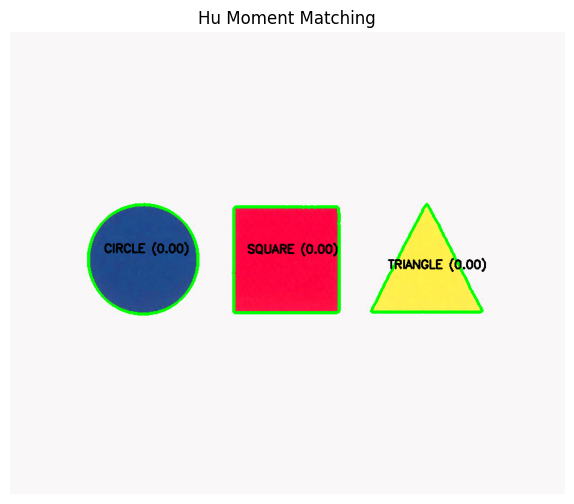

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_reference_contours():
    """Generates baseline contours for mathematically perfect shapes."""
    refs = {}
    for shape in ['circle', 'square', 'triangle']:
        temp = np.zeros((200, 200), dtype=np.uint8)

        if shape == 'circle':
            cv2.circle(temp, (100, 100), 70, 255, -1)

        elif shape == 'square':
            cv2.rectangle(temp, (40, 40), (160, 160), 255, -1)

        elif shape == 'triangle':
            # THE FIX: Draw a perfect Equilateral triangle (Base=120, Height=104)
            # This perfectly matches the proportions of the triangle in your photo.
            pts = np.array([[100, 48], [40, 152], [160, 152]], np.int32)
            cv2.fillPoly(temp, [pts], 255)

        cnts, _ = cv2.findContours(temp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        refs[shape] = cnts[0]

    return refs

# 1. Load Image
image_path = 'shapes.jpg'
img = cv2.imread(image_path)

if img is not None:
    # 2. Preprocess
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 240, 255, cv2.THRESH_BINARY_INV)

    # 3. Find Contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    references = get_reference_contours()
    output = img.copy()

    # 4. Strict Hu Moment Classification
    for cnt in contours:
        if cv2.contourArea(cnt) < 500:
            continue

        best_match = None
        min_dist = float('inf')

        for name, ref_cnt in references.items():
            # THE FIX 2: Use CONTOURS_MATCH_I1.
            # It creates a sharper mathematical distinction between basic shapes.
            dist = cv2.matchShapes(ref_cnt, cnt, cv2.CONTOURS_MATCH_I1, 0)

            if dist < min_dist:
                min_dist = dist
                best_match = name

        # 5. Draw and Label
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
            cv2.drawContours(output, [cnt], -1, (0, 255, 0), 3)

            label = f"{best_match.upper()} ({min_dist:.2f})"
            cv2.putText(output, label, (cx - 60, cy - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    # 6. Display
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Hu Moment Matching")
    plt.axis('off')
    plt.show()
else:
    print(f"Error: Could not find {image_path}. Please upload it to Colab.")